In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [109]:
df = pd.read_csv('X_selected.csv')

In [110]:
df.head(10)

,eccentricity,circularity,cell_area_px,lobularity_score,nucleus_area_pct,perimeter_px,membrane_smoothness,cell_diameter_um,mean_r,stain_intensity,hemoglobin_g_dl,rbc_count_millions_per_ul,patient_age_group,mcv_fl,mean_b,patient_sex,hematocrit_pct,anomaly_labels
0,0.529,0.563,445,6.6,58.8,90,0.800,15.18,215,0.555,11.7,4.44,1,85.5,160,0,43.4,1
1,0.443,0.859,383,6.3,73.6,61,0.737,16.47,189,0.692,13.9,4.90,1,92.5,169,1,42.2,1
2,0.407,0.781,418,3.2,55.5,52,0.790,13.41,193,0.593,16.1,5.72,0,76.3,203,1,39.2,0
3,0.167,0.880,217,1.0,0.0,39,0.937,7.36,227,0.509,14.6,3.42,0,92.3,118,0,54.1,0
4,0.158,1.000,147,1.0,0.0,50,0.925,7.53,239,0.607,14.6,5.36,1,83.9,113,1,36.7,0
5,0.351,0.777,551,1.0,57.8,96,0.848,14.97,189,0.805,14.9,2.70,1,93.7,170,0,37.2,1
6,0.312,0.559,579,1.0,63.3,80,0.696,15.63,196,0.570,14.7,4.01,0,80.9,176,0,39.6,0
7,0.045,0.820,277,1.0,78.3,63,0.886,9.15,191,0.789,10.9,4.04,2,88.5,204,1,38.4,0
8,0.761,0.288,449,1.1,92.9,78,0.440,10.10,164,0.612,13.8,5.07,0,80.6,218,1,43.6,1
9,0.575,0.785,556,1.0,64.1,95,0.723,16.97,204,0.660,9.9,4.36,2,66.3,201,1,43.4,0


In [111]:
df.dtypes

eccentricity                 float64
circularity                  float64
cell_area_px                   int64
lobularity_score             float64
nucleus_area_pct             float64
perimeter_px                   int64
membrane_smoothness          float64
cell_diameter_um             float64
mean_r                         int64
stain_intensity              float64
hemoglobin_g_dl              float64
rbc_count_millions_per_ul    float64
patient_age_group              int64
mcv_fl                       float64
mean_b                         int64
patient_sex                    int64
hematocrit_pct               float64
anomaly_labels                 int64
dtype: object

## Implement Isolation Forest 

In [112]:
from sklearn.ensemble import IsolationForest

In [113]:
iso = IsolationForest(contamination='auto', random_state= 42,n_estimators=200) # choose contamination by using mean = (sum of all anomaly values)/count, in case you already have anomaly_labels
y = df['anomaly_labels'].copy()
X = df.drop(columns= 'anomaly_labels').copy()
iso.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


'auto' give us the percent of points that have anomaly score s(x) lower than -0.5?

contamination is the proportion of outlier in the dataset

In [114]:
### prediction results 
pred = iso.predict(X)

In [115]:
### calculate anomaly score 
scores = iso.score_samples(X)
scores

array([-0.51038782, -0.49953407, -0.45781333, ..., -0.45765386,
       -0.44311523, -0.45643511], shape=(5880,))

In [116]:
df['anomaly'] = pred 
df['anomaly_score'] = scores 

In [117]:
df['anomaly'].value_counts()

anomaly
 1    4765
-1    1115
Name: count, dtype: int64

In [118]:
df[df['anomaly'] == -1].describe()

,eccentricity,circularity,cell_area_px,lobularity_score,nucleus_area_pct,perimeter_px,membrane_smoothness,cell_diameter_um,mean_r,stain_intensity,hemoglobin_g_dl,rbc_count_millions_per_ul,patient_age_group,mcv_fl,mean_b,patient_sex,hematocrit_pct,anomaly_labels,anomaly,anomaly_score
count,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.000000,1115.0,1115.000000
mean,0.550919,0.603841,270.509417,1.480179,31.941435,58.543498,0.767090,8.281238,210.953363,0.588797,13.629148,4.819291,0.904933,89.018296,162.643049,0.513901,40.935785,0.643049,-1.0,-0.523625
std,0.252685,0.215015,224.215606,1.295695,37.216489,30.012544,0.123137,4.877877,22.674014,0.121665,2.323794,0.936234,0.877570,11.335916,34.089147,0.500031,6.329840,0.479315,0.0,0.020580
min,0.027000,0.100000,10.000000,1.000000,0.000000,8.000000,0.290000,1.000000,123.000000,0.307000,6.200000,2.170000,0.000000,60.300000,94.000000,0.000000,20.800000,0.000000,-1.0,-0.602419
25%,0.345000,0.418500,74.000000,1.000000,0.000000,33.000000,0.697000,3.800000,197.000000,0.497500,12.000000,4.140000,0.000000,80.900000,131.000000,0.000000,36.400000,0.000000,-1.0,-0.533586
50%,0.534000,0.625000,186.000000,1.000000,0.000000,59.000000,0.774000,7.460000,214.000000,0.564000,13.700000,4.810000,1.000000,89.200000,165.000000,1.000000,40.900000,1.000000,-1.0,-0.518453
75%,0.777500,0.781500,460.000000,1.100000,68.650000,84.000000,0.856000,12.660000,227.000000,0.665000,15.300000,5.500000,2.000000,96.400000,190.000000,1.000000,45.300000,1.000000,-1.0,-0.507418
max,0.990000,1.000000,901.000000,7.200000,99.000000,126.000000,1.000000,20.350000,255.000000,1.000000,20.000000,7.000000,2.000000,120.000000,244.000000,1.000000,60.000000,1.000000,-1.0,-0.500050


In [119]:
pct_abnormal = (scores < -0.5).mean() * 100
print(f"{pct_abnormal:.2f}% of points have score < -0.5")

18.96% of points have score < -0.5


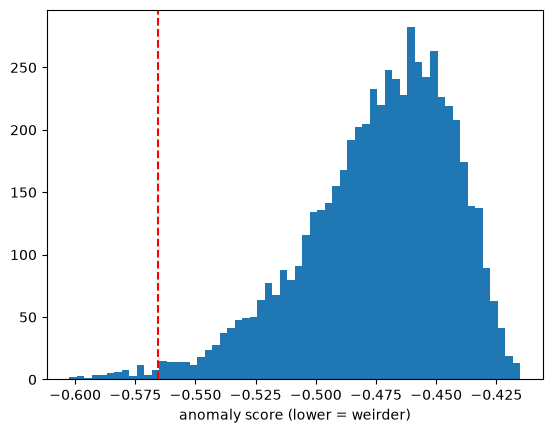

In [120]:
# a) score distribution — works for any number of features
plt.hist(df['anomaly_score'], bins=60)
plt.axvline(df['anomaly_score'].quantile(0.01), color='red', ls='--')
plt.xlabel('anomaly score (lower = weirder)'); plt.show()


# # b) PCA projection for a faithful 2D picture
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler
# # coords = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
# plt.scatter(coords[:,0], coords[:,1],
#             c=df['anomaly'].map({1:'blue',-1:'red'}), alpha=0.5, s=10)
# plt.show()

## Evaluate the Model

In [121]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from IPython.display import display
# Convert iso output (-1/1) to match your label convention (1/0)
y_true = y               # 1 = anomaly, 0 = normal
y_pred = (df['anomaly'] == -1).astype(int)   # 1 = anomaly, 0 = normal
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=pd.Index(["Actual 0", "Actual 1"], name="Actual"),
    columns=pd.Index(["Predicted 0", "Predicted 1"], name="Predicted")
)

display(cm_df)

Predicted,Predicted 0,Predicted 1
Actual,,
Actual 0,3602,398
Actual 1,1163,717


3602 — normal cells correctly called normal ✓ (true negatives)

398 — normal cells wrongly flagged as anomaly ✗ (false alarms)

1163 — real anomalies missed, called normal ✗ (the big problem)

717 — real anomalies correctly caught ✓ (true positives)

In [122]:
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.756     0.900     0.822      4000
           1      0.643     0.381     0.479      1880

    accuracy                          0.735      5880
   macro avg      0.699     0.641     0.650      5880
weighted avg      0.720     0.735     0.712      5880



### Class 1 — anomalies (the class you actually care about)

Recall 0.381 → caught only 38% of real anomalies. Missed 62%. This is the main weakness. For medical screening, missing most abnormal cells is a serious failure.

Precision 0.643 → when it flags an anomaly, it's right ~64% of the time. Decent, but not the problem.

F1 0.479 → low, dragged down by the weak recall.

### Class 0 — normal cells

Precision 0.756, recall 0.900, F1 0.822 — looks strong, but this is the easy class. There are lots of normal cells, so getting them right is not impressive on its own.